In [3]:
from sklearn.utils import resample
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

import numpy as np
from sklearn.utils import resample

def bootstrap_imputation(df, column: str, n_bootstrap: int = 100, hour_window: int = 2) -> pd.Series:
    """
    Strategy 6 (stochastic version): Bootstrap using values from same hour of day across years,
    but assign random draws instead of averaging to preserve variability.
    
    Args:
        df: DataFrame containing the data
        column: Column name to impute
        n_bootstrap: Number of bootstrap samples (not used for averaging anymore, 
                     but can be used to draw a larger random pool if desired)
        hour_window: Window around target hour (±hours)
    
    Returns:
        Series with imputed values
    """
    result = df[column].copy()
    missing_mask = result.isna()
    
    for idx in df[missing_mask].index:
        target_hour = df.loc[idx, 'hour']
        
        # Collect values from similar hours across all years
        bootstrap_pool = []
        for h in range(max(0, target_hour - hour_window), 
                        min(24, target_hour + hour_window + 1)):
            hour_candidates = df[
                (df['hour'] == h) & 
                (~df[column].isna())
            ][column]
            bootstrap_pool.extend(hour_candidates.tolist())
        
        if bootstrap_pool:
            # Instead of averaging bootstrap samples, pick a random draw
            result.loc[idx] = np.random.choice(bootstrap_pool)
    
    return result


In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


def plot_n_trees_vs_error(X_train, y_train, X_valid, y_valid):
    errors = []
    estimators_range = range(10, 1001, 50)

    for n in estimators_range:
        rf = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_valid)
        errors.append(mean_squared_error(y_valid, y_pred))

    plt.plot(estimators_range, errors)
    plt.xlabel("Number of Trees")
    plt.ylabel("Validation MSE")
    plt.title("Random Forest: # Trees vs Error")
    plt.show()

Imputing pm10...
Imputing pm2.5...
Imputing wsr...
Imputing prs...
Imputing rh...
Imputing sr...
Imputing tout...
Imputing wdr...
Imputation complete.
pm10 Random Forest MSE: 1926.2442395532319


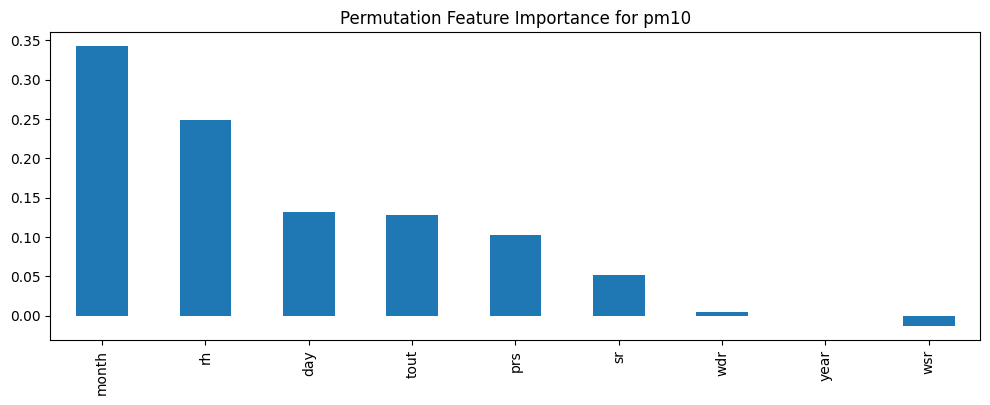

c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\valid

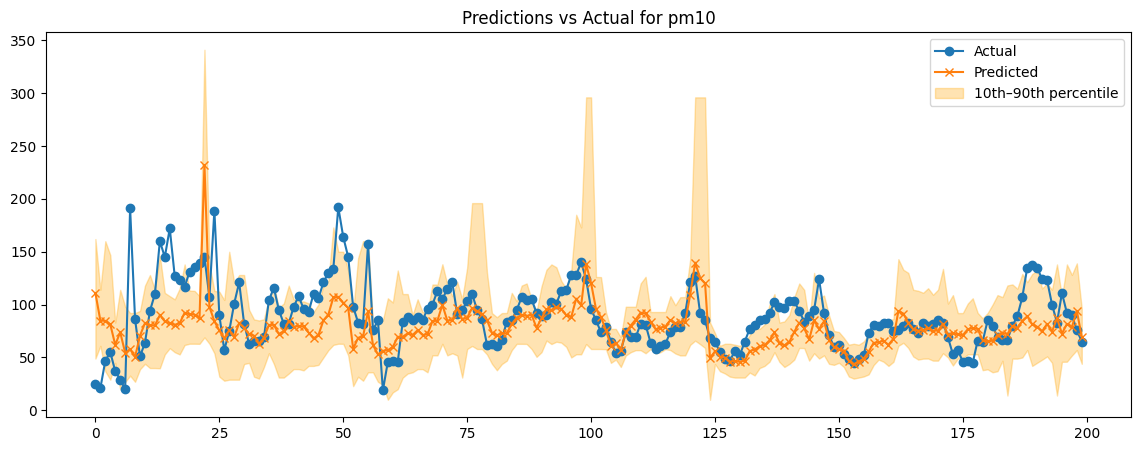

Cross-Validation MSE: -1790.90
pm2.5 Random Forest MSE: 316.83167698193915


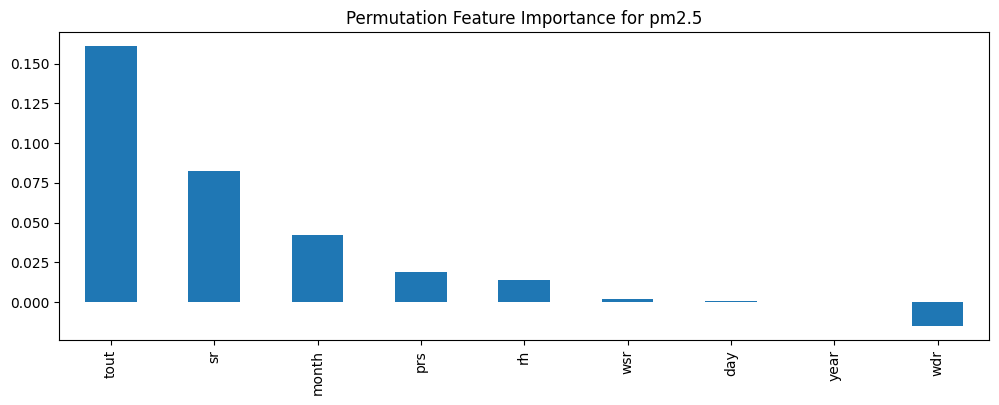

c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\venv\Lib\site-packages\sklearn\utils\valid

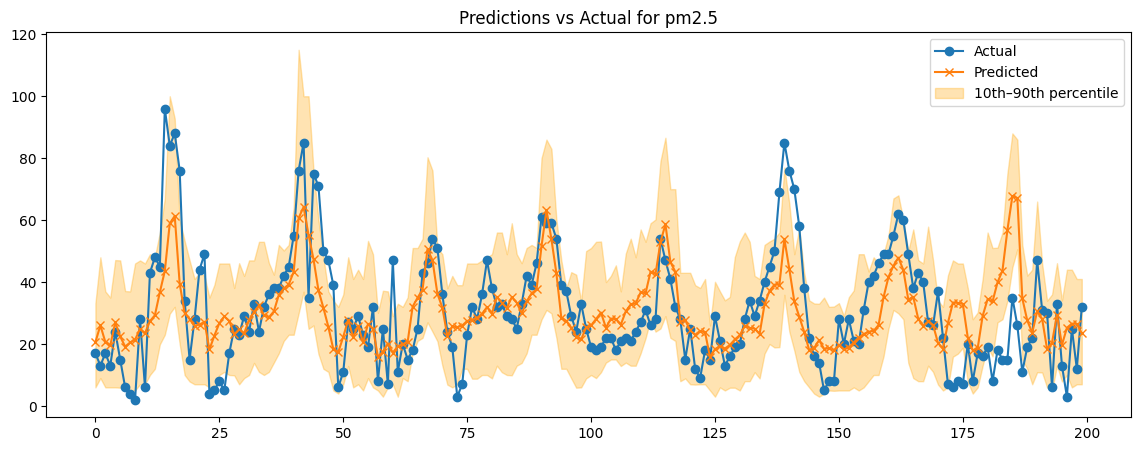

Cross-Validation MSE: -232.45
Percentage of actual values within 10th–90th percentile for pm10: 60.46%


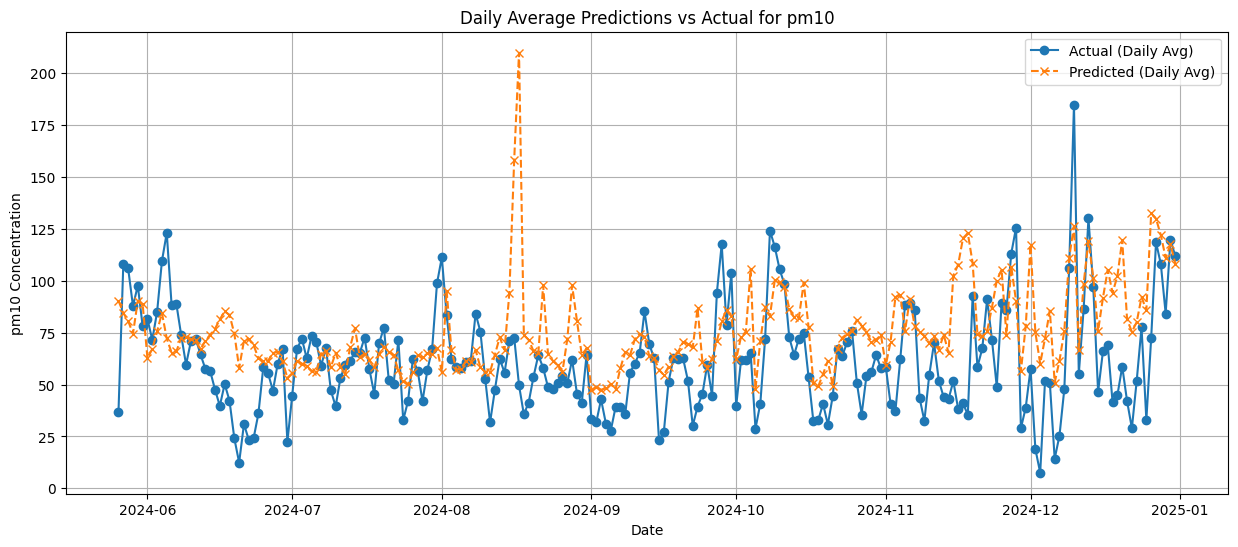

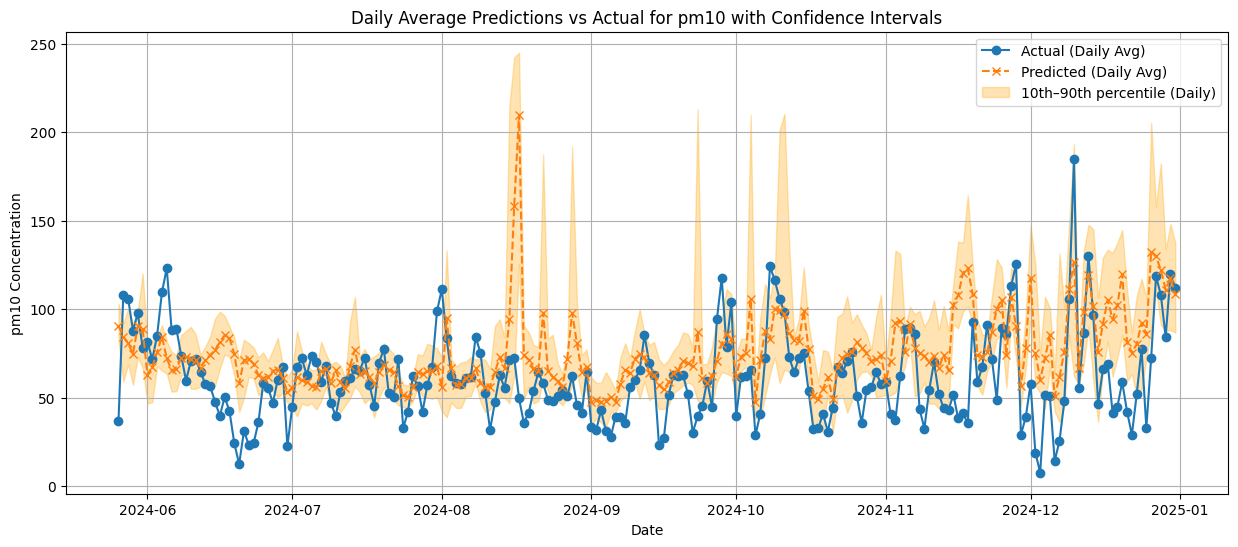

Percentage of actual values within 10th–90th percentile for pm2.5: 71.63%


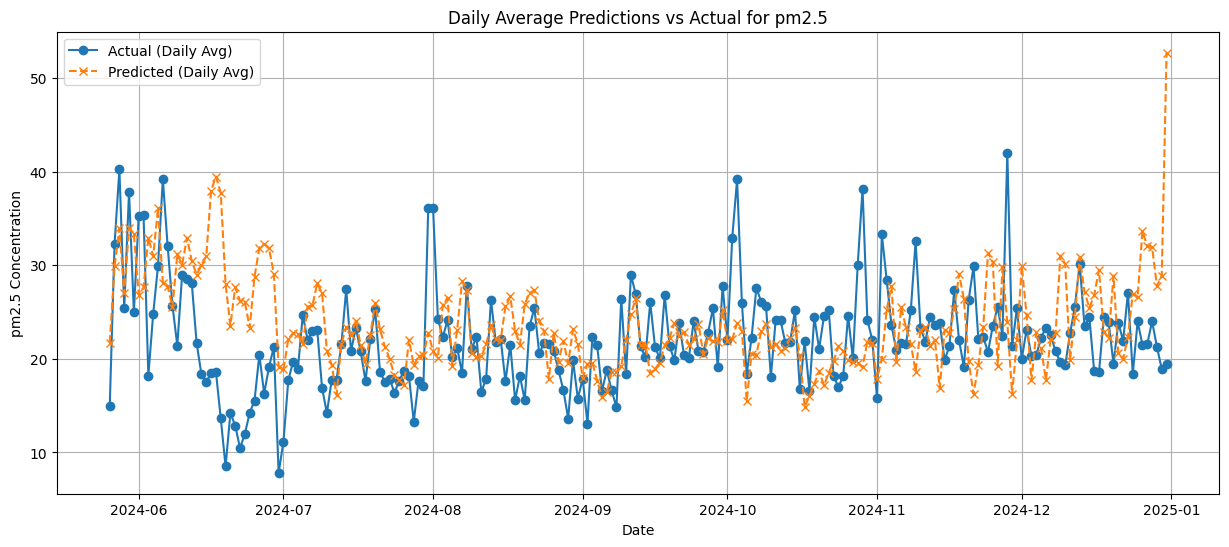

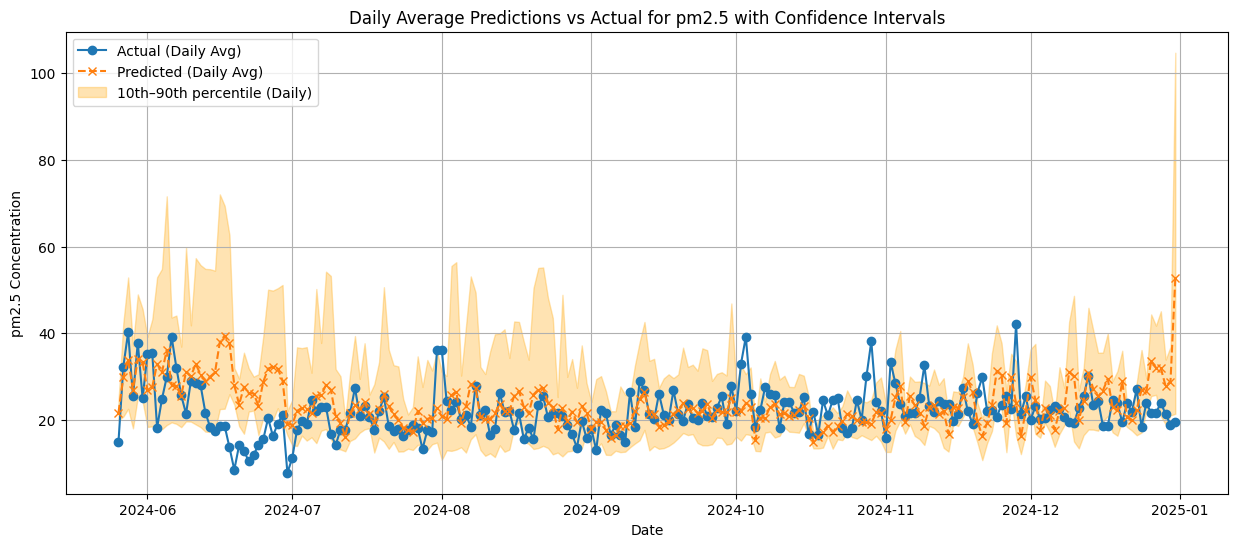

In [ ]:
# Load data
df = pd.read_csv("estacion_data.csv", parse_dates=["date_index"])

# Define columns to impute
weather_vars_to_impute = ['wsr', 'prs', 'rh', 'sr', 'tout', 'wdr']
pollutants_to_impute = ['pm10', 'pm2.5']
columns_to_impute = pollutants_to_impute + weather_vars_to_impute


# Drop unnecessary columns
df_numeric = df.drop(['date_index', 'co', 'no', 'no2', 'nox', 'o3', 'so2', 'archivo_origen', 'estacion', 'rainf'], axis=1, errors='ignore')

cov_matrix = df_numeric.cov()

mahalanobis_distance = np.sqrt(np.sum((df_numeric - df_numeric.mean()) @ np.linalg.inv(cov_matrix) * (df_numeric - df_numeric.mean()), axis=1))

threshold = 3
outliers = mahalanobis_distance > (mahalanobis_distance.mean() + threshold * mahalanobis_distance.std())

df = df[~outliers]

df = df.drop(['co', 'no', 'no2', 'nox', 'o3', 'so2', 'archivo_origen', 'estacion', 'rainf'], axis=1, errors='ignore')

# Extract date components
df['year'] = df['date_index'].dt.year
df['month'] = df['date_index'].dt.month
df['day'] = df['date_index'].dt.day
df['hour'] = df['date_index'].dt.hour

# Define time of day
def time_of_day(hour):
    if 0 <= hour < 6:
        return "early_morning"
    elif 6 <= hour < 12:
        return "morning"
    elif 12 <= hour < 18:
        return "afternoon"
    else:
        return "night"

df['time_of_day'] = df['hour'].apply(time_of_day)

# Impute missing values for all specified columns
for col in columns_to_impute:
    print(f"Imputing {col}...")
    df[col] = bootstrap_imputation(df, col)
print("Imputation complete.")


# Define predictors and pollutants
# Corrected weather variables
weather_vars = ['wsr', 'prs', 'rh', 'sr', 'tout', 'wdr']
date_vars = ['year', 'month', 'day']
categorical_vars = ['time_of_day']
pollutants = ['pm10', 'pm2.5']


# One-hot encode time_of_day
df_clean = pd.get_dummies(df, columns=categorical_vars, drop_first=False)

# Train Random Forest for each pollutant
predictors = weather_vars + date_vars + [col for col in df.columns if col.startswith('time_of_day_')]

# Store results for plotting
results = {}



for pollutant in pollutants:
    df_model = df_clean.copy() # Use the cleaned and imputed data
    X = df_model[predictors]
    y = df_model[f'{pollutant}']
    
    # Keep track of indices for plotting later
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    
    mse = mean_squared_error(y_test, y_pred)
    print(f"{pollutant} Random Forest MSE:", mse)
    
    # Feature importance
    from sklearn.inspection import permutation_importance
    
    # Calculate permutation importance
    perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
    
    # Create Series with feature names and importance values
    importances = pd.Series(perm_importance.importances_mean, index=X.columns).sort_values(ascending=False)
    
    plt.figure(figsize=(12,4))
    importances.plot(kind='bar')
    plt.title(f"Permutation Feature Importance for {pollutant}")
    plt.show()
    
    # Get predictions from each tree
    all_tree_preds = np.array([tree.predict(X_test) for tree in rf.estimators_])  # shape: (n_trees, n_samples)

    # Mean prediction
    y_pred_mean = all_tree_preds.mean(axis=0)

    # 10th and 90th percentiles
    y_pred_10th = np.percentile(all_tree_preds, 10, axis=0)
    y_pred_90th = np.percentile(all_tree_preds, 90, axis=0)
    
    # Store results for later plotting
    results[pollutant] = {
        'y_test': y_test,
        'y_pred_mean': y_pred_mean,
        'y_pred_10th': y_pred_10th,
        'y_pred_90th': y_pred_90th,
        'X_test': X_test
    }
    
    # Predictions vs Actual with 90th percentile upper bound
    plt.figure(figsize=(14,5))

    # Limit to first 200 points for readability
    n_points = 200
    x_vals = np.arange(n_points)

    plt.plot(x_vals, y_test.values[:n_points], label="Actual", marker='o')
    plt.plot(x_vals, y_pred_mean[:n_points], label="Predicted", marker='x')

    # Plot 10th–90th percentile range as shaded area
    plt.fill_between(
        x_vals,
        y_pred_10th[:n_points],
        y_pred_90th[:n_points],
        color='orange', alpha=0.3, label='10th–90th percentile'
    )

    plt.title(f"Predictions vs Actual for {pollutant}")
    plt.legend()
    plt.show()

    scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error')
    print(f"Cross-Validation MSE: {scores.mean():.2f}")

# Apply the plotting code from file_context_0 for each pollutant
for pollutant in pollutants:
    y_test = results[pollutant]['y_test']
    y_pred_mean = results[pollutant]['y_pred_mean']
    y_pred_10th = results[pollutant]['y_pred_10th']
    y_pred_90th = results[pollutant]['y_pred_90th']
    
    # Calculate the percentage of actual values that fall within the 10th-90th percentile range
    within_interval = (y_test.values >= y_pred_10th) & (y_test.values <= y_pred_90th)
    percentage_in_interval = np.mean(within_interval) * 100
    print(f"Percentage of actual values within 10th–90th percentile for {pollutant}: {percentage_in_interval:.2f}%")

    # Create a dataframe for daily aggregation
    daily_df = pd.DataFrame({
        'date': df.loc[y_test.index, 'date_index'].dt.date,
        'actual': y_test,
        'predicted': y_pred_mean
    })

    # Group by date and calculate the mean
    daily_agg = daily_df.groupby('date').mean()

    # Plot daily aggregated predictions vs actuals
    plt.figure(figsize=(15, 6))
    plt.plot(daily_agg.index, daily_agg['actual'], label='Actual (Daily Avg)', marker='o', linestyle='-')
    plt.plot(daily_agg.index, daily_agg['predicted'], label='Predicted (Daily Avg)', marker='x', linestyle='--')
    plt.title(f'Daily Average Predictions vs Actual for {pollutant}')
    plt.xlabel('Date')
    plt.ylabel(f'{pollutant} Concentration')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Add confidence intervals to the daily plot
    plt.figure(figsize=(15, 6))
    plt.plot(daily_agg.index, daily_agg['actual'], label='Actual (Daily Avg)', marker='o', linestyle='-')
    plt.plot(daily_agg.index, daily_agg['predicted'], label='Predicted (Daily Avg)', marker='x', linestyle='--')

    # Add confidence intervals (assuming we have daily aggregated confidence intervals)
    # You'll need to calculate these from your prediction intervals
    daily_agg_10th = daily_df.groupby('date')['predicted'].quantile(0.1)
    daily_agg_90th = daily_df.groupby('date')['predicted'].quantile(0.9)

    plt.fill_between(
        daily_agg.index,
        daily_agg_10th,
        daily_agg_90th,
        color='orange', alpha=0.3, label='10th–90th percentile (Daily)'
    )
    plt.title(f'Daily Average Predictions vs Actual for {pollutant} with Confidence Intervals')
    plt.xlabel('Date')
    plt.ylabel(f'{pollutant} Concentration')
    plt.legend()
    plt.grid(True)
    plt.show()




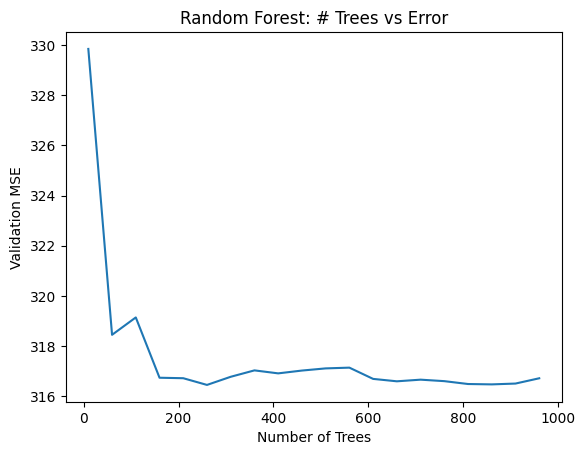

In [14]:
plot_n_trees_vs_error(X_train, y_train, X_test, y_test)

In [ ]:
rf.get_params()



{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 200,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}